<a href="https://colab.research.google.com/github/dharmendra-developer/Google_Colab/blob/main/Student_Performance_Prediction_%26_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction & Recommendation System

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sns

In [ ]:
data = pd.read_csv('StudentPerformanceFactors.csv')
pd.DataFrame(data)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [ ]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
data.dropna(inplace=True)

In [ ]:
data['Exam_Score'].unique()



array([ 67,  61,  74,  71,  70,  66,  69,  72,  68,  65,  64,  60,  63,
        62, 100,  76,  79,  73,  78,  89,  75,  59,  86,  97,  83,  84,
        80,  58,  94,  55,  92,  82,  77, 101,  88,  91,  99,  87,  57,
        96,  98,  95,  85,  93,  56])

In [ ]:
data['Hours_Studied'].unique()

array([23, 19, 24, 29, 25, 17, 21,  9, 10, 14, 22, 15, 12, 20, 11, 13, 16,
       18, 31,  8, 26, 28,  4, 35, 27, 33, 36, 43, 34,  1, 30,  7, 32,  6,
       38,  5,  3, 39,  2, 37, 44])

In [ ]:
data['Attendance'].unique()

array([ 84,  64,  98,  89,  92,  88,  78,  94,  80,  97,  83,  82,  68,
        60,  70,  75,  99,  74,  65,  62,  91,  90,  66,  69,  72,  63,
        61,  86,  77,  71,  67,  87,  73,  96, 100,  81,  95,  79,  85,
        76,  93])

In [ ]:
# x=data[['Hours_Studied','Attendance']]
# y=data['Exam_Score']
x = data[['Hours_Studied', 'Attendance','Sleep_Hours']]
y = data['Exam_Score']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
x_train

array([[-0.32767187,  1.29777176, -0.03232325],
       [-0.66082888,  0.77858843,  0.64913637],
       [-0.66082888, -0.95202267, -0.71378287],
       ...,
       [ 0.67179916, -1.29814488, -0.03232325],
       [ 1.67127019,  0.95164954, -0.03232325],
       [ 1.33811318,  1.21124121, -0.03232325]])

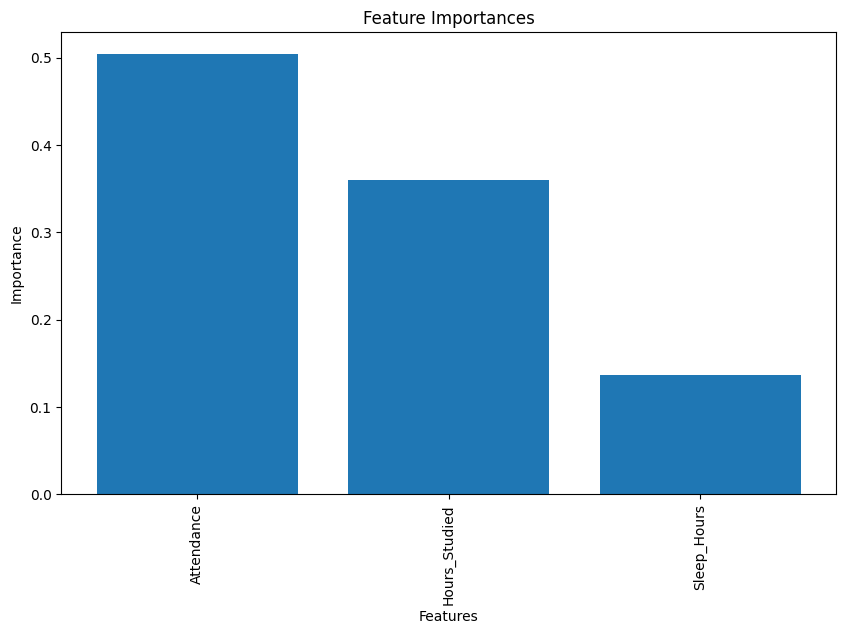

In [ ]:
importances= rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), np.array(x.columns)[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()


In [ ]:
y_pred = rf.predict(x_train)
print(y_pred)

[68.29333333 67.52433333 62.89133333 ... 64.07516667 74.69
 72.604     ]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_train, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y_train, y_pred)
print("R^2 Score:", r2)

Mean Squared Error: 3.031321885025721
R^2 Score: 0.8013992323911453


In [ ]:
pd.DataFrame(np.c_[x_train, y_train, y_pred], columns=['Hours_Studied', 'Attendance','Sleep_Hours', 'Actual_Exam_Score', 'Predicted_Exam_Score'])

,Hours_Studied,Attendance,Sleep_Hours,Actual_Exam_Score,Predicted_Exam_Score
0,-0.327672,1.297772,-0.032323,70.0,68.293333
1,-0.660829,0.778588,0.649136,67.0,67.524333
2,-0.660829,-0.952023,-0.713783,62.0,62.891333
3,-1.493721,-1.298145,-0.032323,63.0,62.850000
4,0.172064,1.297772,0.649136,69.0,69.387667
...,...,...,...,...,...
5097,1.671270,-0.865492,-0.713783,70.0,69.528000
5098,0.671799,0.865119,1.330596,71.0,68.210000
5099,0.671799,-1.298145,-0.032323,64.0,64.075167
5100,1.671270,0.951650,-0.032323,75.0,74.690000


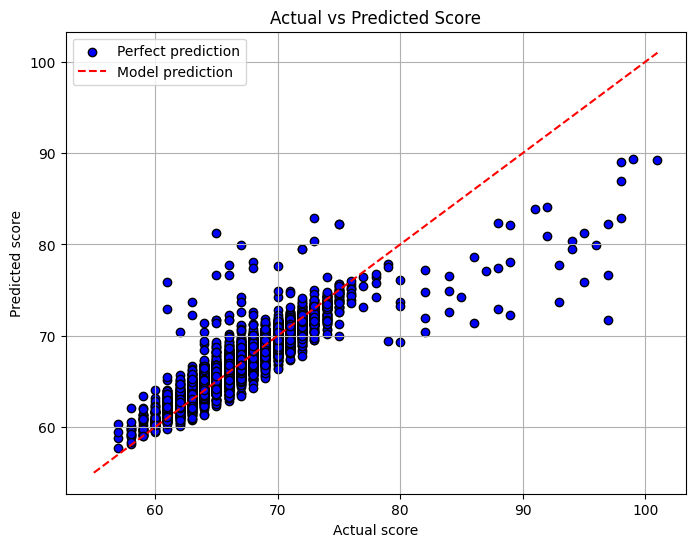

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_train, y_pred, color="blue", edgecolor="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.title("Actual vs Predicted Score")
plt.grid()
plt.legend(["Perfect prediction", "Model prediction"])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
new_student = pd.DataFrame([[2, 80, 8]],
                           columns=['Hours_Studied','Attendance','Sleep_Hours'])


In [ ]:
new_student_scaled = scaler.transform(new_student)
predicted_score = rf.predict(new_student_scaled)[0]
print("Predicted Exam Score:", round(predicted_score, 2))

Predicted Exam Score: 60.09


In [ ]:
def recommend_rules(student, predicted_score):
    recs = []

    # Study hours recommendation
    if student['Hours_Studied'].values[0] < 5:
        recs.append("📘 Increase study time to at least 2 hours per day")

    # Attendance recommendation
    if student['Attendance'].values[0] < 60:
        recs.append("🏫 Improve attendance for better consistency")

    # Sleep recommendation
    if student['Sleep_Hours'].values[0] > 9:
        recs.append("😴 Reduce sleep by 1 hour and use that time for revision")
    elif student['Sleep_Hours'].values[0] < 6:
        recs.append("⚡ Increase sleep to at least 7 hours for better focus")

    # Prediction-based recommendation
    if predicted_score < 50:
        recs.append("🚀 Focus more on weak areas, join extra tutoring sessions")
    elif predicted_score < 70:
        recs.append("💡 Good effort! Revise regularly to boost performance")
    else:
        recs.append("🌟 Excellent! Keep up the great work and aim even higher")

    return recs

for r in recommend_rules(new_student, predicted_score):
    print("-", r)


- 📘 Increase study time to at least 2 hours per day
- 💡 Good effort! Revise regularly to boost performance


In [ ]:
# User input
hours = float(input("Enter study hours per day: "))
attendance = float(input("Enter attendance percentage: "))
sleep = float(input("Enter average sleep hours per day: "))

# Convert to DataFrame
new_student = pd.DataFrame([[hours, attendance, sleep]],
                           columns=['Hours_Studied','Attendance','Sleep_Hours'])

# Scaling (same scaler used before training)
new_student_scaled = scaler.transform(new_student)

# Prediction
predicted_score = rf.predict(new_student_scaled)[0]
print("\nPredicted Exam Score:", round(predicted_score, 2))

# Recommendations
print("\n📌 Recommendations:")
for r in recommend_rules(new_student, predicted_score):
    print("-", r)


Enter study hours per day: 6
Enter attendance percentage: 75
Enter average sleep hours per day: 9

Predicted Exam Score: 62.7

📌 Recommendations:
- 💡 Good effort! Revise regularly to boost performance
